# CNN

In [ ]:
import tensorflow 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
import tensorflow.keras as tf 

In [4]:
# data load 
(x_train, y_train), (x_test,y_test) = tensorflow.keras.datasets.mnist.load_data()

In [5]:
X_train = x_train / 255.0
X_test = x_test / 255.0

X_train = X_train.reshape(-1, 28,28,1)
X_test = x_test.reshape(-1,28,28,1)

# y_train_cat = to_categorical(y_train, 10)
# y_test_cat = to_categorical(y_test, 10)

In [ ]:
model = Sequential([
    Conv2D(32,kernel_size=(3,3),activation= 'relu',input_shape = (28,28,1),),
    MaxPooling2D(),
    BatchNormalization(),

    Conv2D(64, kernel_size= (3,3), activation= 'relu'),
    MaxPooling2D(),
    BatchNormalization(),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(10,activation= 'softmax')

])

c:\Users\iamso\Desktop\BIOIN_Souvik\dl\dl_env2\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer= 'adam', loss= 'sparse_categorical_crossentropy', metrics= ['accuracy'])

In [8]:
history = model.fit(X_train, y_train, epochs= 3, validation_split= 0.2 , batch_size= 32, verbose= 1)

Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9619 - loss: 0.1253 - val_accuracy: 0.9835 - val_loss: 0.0585
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9839 - loss: 0.0537 - val_accuracy: 0.9839 - val_loss: 0.0592
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9880 - loss: 0.0400 - val_accuracy: 0.9868 - val_loss: 0.0455


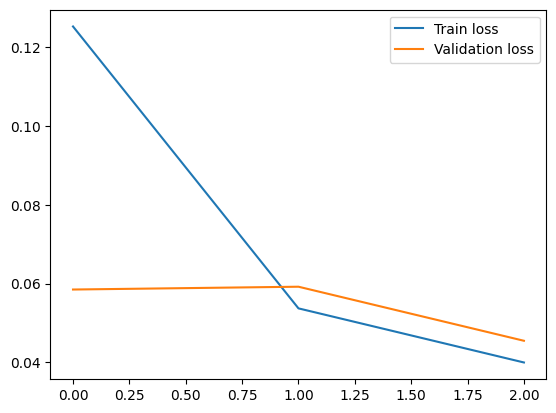

In [9]:
import matplotlib.pyplot as plt 

plt.plot(history.history['loss'] , label= 'Train loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.legend()
plt.show()

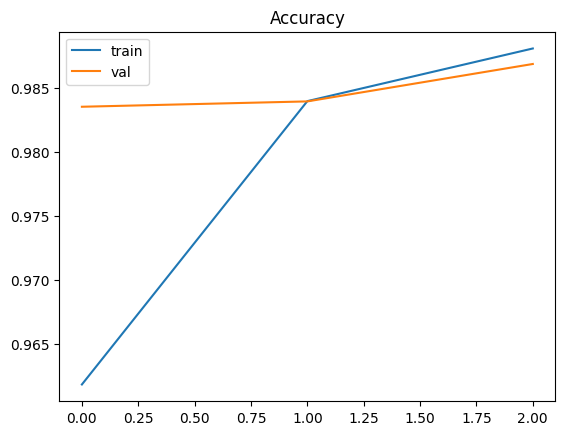

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['train','val'])
plt.show()

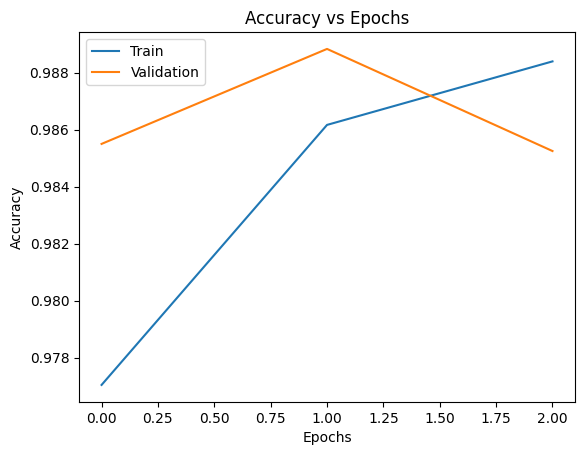

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [16]:
import numpy as np 
y_pred =  model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.81      0.89       980
           1       0.00      0.00      0.00      1135
           2       0.96      0.75      0.84      1032
           3       0.98      0.93      0.96      1010
           4       0.82      0.99      0.89       982
           5       0.99      0.94      0.96       892
           6       0.93      0.98      0.96       958
           7       1.00      0.80      0.89      1028
           8       0.37      1.00      0.54       974
           9       0.95      0.88      0.91      1009

    accuracy                           0.79     10000
   macro avg       0.80      0.81      0.78     10000
weighted avg       0.79      0.79      0.77     10000



c:\Users\iamso\Desktop\BIOIN_Souvik\dl\dl_env2\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iamso\Desktop\BIOIN_Souvik\dl\dl_env2\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\iamso\Desktop\BIOIN_Souvik\dl\dl_env2\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri